# To mention

- There was a problem with the matching in DEH files 
- Really low statistical power (I think some s.d. of some estimators cannot be even estimated, probably not)

In [16]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import seaborn as sns
from scipy.stats import spearmanr

In [8]:
df_D4500 = pd.read_csv("output_4500/satuRn_DTU_transcripts_D_vs_WM_with_deltaUsage_D4500.csv")
df_DAH = pd.read_csv("output_DAH/satuRn_DTU_transcripts_D_vs_WM_with_deltaUsage_DAH.csv")
df_DEH = pd.read_csv("output_DEH/satuRn_DTU_transcripts_D_vs_WM_with_deltaUsage_DEH.csv")

In [ ]:
df_D4500

,isoform_id,gene_id,estimates,se,df,t,pval,regular_FDR,empirical_pval,empirical_FDR,padj,mean_usage_WM,mean_usage_D,delta_usage
0,ENST00000374003.7,ENSG00000000938.13,2.425935,0.068442,2.877346,35.445055,0.000069,0.009139,NaN,NaN,0.033387,0.014028,0.139713,0.125685
1,ENST00000374005.8,ENSG00000000938.13,-1.343853,0.026905,2.877346,-49.947719,0.000026,0.009139,NaN,NaN,0.033387,0.602849,0.283653,-0.319196
2,ENST00000584106.1,ENSG00000002834.18,2.029267,0.095694,2.877346,21.205823,0.000299,0.020228,NaN,NaN,0.033387,0.026976,0.173612,0.146636
3,ENST00000341222.10,ENSG00000003402.21,2.590576,0.106538,2.877346,24.315888,0.000202,0.020213,NaN,NaN,0.033387,0.016491,0.179464,0.162973
4,ENST00000444129.7,ENSG00000004700.16,-1.560886,0.073972,2.877346,-21.100997,0.000303,0.020228,NaN,NaN,0.033387,0.798590,0.452198,-0.346392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60675,ENST00000378292.9,ENSG00000198467.16,NaN,NaN,1.877346,NaN,NaN,NaN,NaN,NaN,NaN,0.640899,0.000000,-0.640899
60676,ENST00000320868.9,ENSG00000206172.8,NaN,NaN,1.877346,NaN,NaN,NaN,NaN,NaN,NaN,0.967196,0.000000,-0.967196
60677,ENST00000487791.1,ENSG00000206172.8,NaN,NaN,1.877346,NaN,NaN,NaN,NaN,NaN,NaN,0.032804,0.000000,-0.032804
60678,ENST00000533010.6,ENSG00000233024.7,NaN,NaN,1.877346,NaN,NaN,NaN,NaN,NaN,NaN,0.065084,0.000000,-0.065084


In [21]:
df_DAH

,isoform_id,gene_id,estimates,se,df,t,pval,regular_FDR,empirical_pval,empirical_FDR,padj,mean_usage_WM,mean_usage_D,delta_usage
0,ENST00000432588.6,ENSG00000075624.17,2.975039,0.015985,3.174442,186.109432,1.615749e-07,0.000032,NaN,NaN,0.005045,0.022994,0.315511,0.292518
1,ENST00000646664.1,ENSG00000075624.17,-3.770758,0.018735,3.174442,-201.265287,1.260226e-07,0.000032,NaN,NaN,0.005045,0.812954,0.091023,-0.721931
2,ENST00000309955.8,ENSG00000003402.21,-0.510963,0.012937,3.174442,-39.495636,2.209987e-05,0.008840,NaN,NaN,0.010852,0.537214,0.410811,-0.126403
3,ENST00000311117.8,ENSG00000005483.22,-2.691785,0.040936,3.174442,-65.756321,4.388616e-06,0.001310,NaN,NaN,0.010852,0.719882,0.148227,-0.571655
4,ENST00000371335.4,ENSG00000005893.16,-2.083746,0.040855,3.174442,-51.003601,9.824599e-06,0.001310,NaN,NaN,0.010852,0.569262,0.142923,-0.426340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62446,ENST00000687619.1,ENSG00000288302.2,0.000000,0.594072,2.174442,0.000000,1.000000e+00,1.000000,NaN,NaN,1.000000,0.250000,0.250000,0.000000
62447,ENST00000684841.1,ENSG00000289315.1,0.000000,0.344166,3.174442,0.000000,1.000000e+00,1.000000,NaN,NaN,1.000000,0.500000,0.500000,0.000000
62448,ENST00000687012.1,ENSG00000289315.1,0.000000,0.344166,3.174442,0.000000,1.000000e+00,1.000000,NaN,NaN,1.000000,0.500000,0.500000,0.000000
62449,ENST00000685428.1,ENSG00000289538.1,0.000000,0.310930,3.174442,0.000000,1.000000e+00,1.000000,NaN,NaN,1.000000,0.500000,0.500000,0.000000


In [22]:
df_DEH

,isoform_id,gene_id,estimates,se,df,t,pval,regular_FDR,empirical_pval,empirical_FDR,padj,mean_usage_WM,mean_usage_D,delta_usage
0,ENST00000261443.9,ENSG00000009307.17,2.672953,0.028792,3.211124,92.836982,1.288129e-06,0.000515,NaN,NaN,0.008412,0.082407,0.564204,0.481798
1,ENST00000432588.6,ENSG00000075624.17,3.656509,0.027489,3.211124,133.017887,4.059988e-07,0.000081,NaN,NaN,0.008412,0.022993,0.475104,0.452110
2,ENST00000646664.1,ENSG00000075624.17,-3.617053,0.023138,3.211124,-156.328078,2.417501e-07,0.000081,NaN,NaN,0.008412,0.812943,0.104807,-0.708136
3,ENST00000306090.12,ENSG00000087460.29,2.587667,0.023378,3.211124,110.685842,7.324613e-07,0.000293,NaN,NaN,0.008412,0.147131,0.695457,0.548327
4,ENST00000597960.7,ENSG00000105701.16,2.404012,0.028402,3.211124,84.641227,1.733039e-06,0.000693,NaN,NaN,0.008412,0.013251,0.129214,0.115962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63199,ENST00000687012.1,ENSG00000289315.1,0.000000,0.354548,3.211124,0.000000,1.000000e+00,1.000000,NaN,NaN,1.000000,0.500000,0.500000,0.000000
63200,ENST00000689566.1,ENSG00000289469.1,0.000000,0.273226,3.211124,0.000000,1.000000e+00,1.000000,NaN,NaN,1.000000,0.500000,0.500000,0.000000
63201,ENST00000692257.1,ENSG00000289469.1,0.000000,0.273226,3.211124,0.000000,1.000000e+00,1.000000,NaN,NaN,1.000000,0.500000,0.500000,0.000000
63202,ENST00000685428.1,ENSG00000289538.1,0.000000,0.333836,3.211124,0.000000,1.000000e+00,1.000000,NaN,NaN,1.000000,0.500000,0.500000,0.000000


In [9]:
def perform_sanity_checks(df, title):
    """
    Performs a series of sanity checks on a DTU results dataframe.

    Args:
        df (pd.DataFrame): The dataframe from your satuRn results.
        title (str): The name of the experiment for titles and print statements.
    """
    print("---" * 15)
    print(f"🔬 Running Sanity Checks for: {title}")
    print("---" * 15)

    # --- 1. Basic Data Integrity ---
    print("\n## 1. Basic Data Integrity ##")
    print(f"Shape of the dataframe: {df.shape[0]} rows, {df.shape[1]} columns")
    
    # Check for missing values in key columns
    missing_vals = df[['pval', 'padj', 'delta_usage']].isnull().sum()
    if missing_vals.sum() > 0:
        print("\n[WARNING] Missing values found in critical columns:")
        print(missing_vals)
    else:
        print("\n[OK] No missing values in 'pval', 'padj', or 'delta_usage'.")

    # --- 2. Statistical Sanity: P-value Distribution ---
    print("\n## 2. P-value Distribution ##")
    print("Plotting p-value histogram...")
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df['pval'], bins=40, kde=False)
    plt.title(f'{title}\nRaw P-value Distribution')
    plt.xlabel('p-value')
    plt.ylabel('Frequency')
    
    # --- 3. Effect Size Sanity: Delta Usage ---
    print("\n## 3. Effect Size (delta_usage) Sanity ##")
    min_du, max_du = df['delta_usage'].min(), df['delta_usage'].max()
    print(f"Delta Usage Range: [{min_du:.3f}, {max_du:.3f}]")
    if min_du >= -1 and max_du <= 1:
        print("[OK] Delta usage values are within the expected [-1, 1] range.")
    else:
        print("[ERROR] Delta usage values are outside the [-1, 1] range!")

    plt.subplot(1, 2, 2)
    sns.histplot(df['delta_usage'], bins=50, kde=True)
    plt.title(f'{title}\nDelta Usage Distribution')
    plt.xlabel('Delta Usage (D - WM)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    # --- 4. Logical Consistency Checks ---
    print("\n## 4. Logical Consistency ##")
    
    # Check if delta_usage calculation is consistent with means
    is_consistent = np.allclose(df['mean_usage_D'] - df['mean_usage_WM'], df['delta_usage'])
    if is_consistent:
        print("[OK] `delta_usage` is consistent with `mean_usage_D` - `mean_usage_WM`.")
    else:
        print("[WARNING] `delta_usage` column does not match `mean_usage_D` - `mean_usage_WM`.")
        
    # Check that significant isoforms have a positive delta_usage or negative
    significant_df = df[df['padj'] < 0.05]
    if not significant_df.empty:
        non_zero_delta = (significant_df['delta_usage'] != 0).all()
        if non_zero_delta:
            print("[OK] All significant isoforms have a non-zero delta_usage.")
        else:
            print("[WARNING] Found significant isoforms with a delta_usage of zero.")
    else:
        print("No significant isoforms to check for logical consistency.")

    print("\nSanity checks complete for this dataframe.\n")

---------------------------------------------
🔬 Running Sanity Checks for: D4500 Depletion
---------------------------------------------

## 1. Basic Data Integrity ##
Shape of the dataframe: 60680 rows, 14 columns

[WARNING] Missing values found in critical columns:
pval           25
padj           25
delta_usage     0
dtype: int64

## 2. P-value Distribution ##
Plotting p-value histogram...

## 3. Effect Size (delta_usage) Sanity ##
Delta Usage Range: [-1.000, 1.000]
[OK] Delta usage values are within the expected [-1, 1] range.


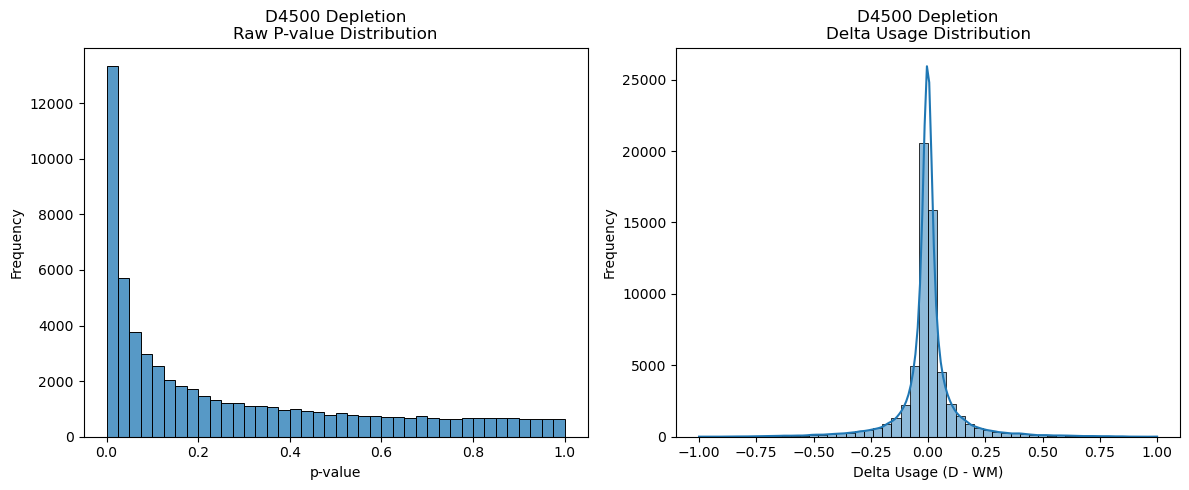


## 4. Logical Consistency ##
[OK] `delta_usage` is consistent with `mean_usage_D` - `mean_usage_WM`.
[OK] All significant isoforms have a non-zero delta_usage.

Sanity checks complete for this dataframe.



In [10]:
perform_sanity_checks(df_D4500, "D4500 Depletion")

---------------------------------------------
🔬 Running Sanity Checks for: DAH Depletion
---------------------------------------------

## 1. Basic Data Integrity ##
Shape of the dataframe: 62451 rows, 14 columns

[OK] No missing values in 'pval', 'padj', or 'delta_usage'.

## 2. P-value Distribution ##
Plotting p-value histogram...

## 3. Effect Size (delta_usage) Sanity ##
Delta Usage Range: [-1.000, 1.000]
[OK] Delta usage values are within the expected [-1, 1] range.


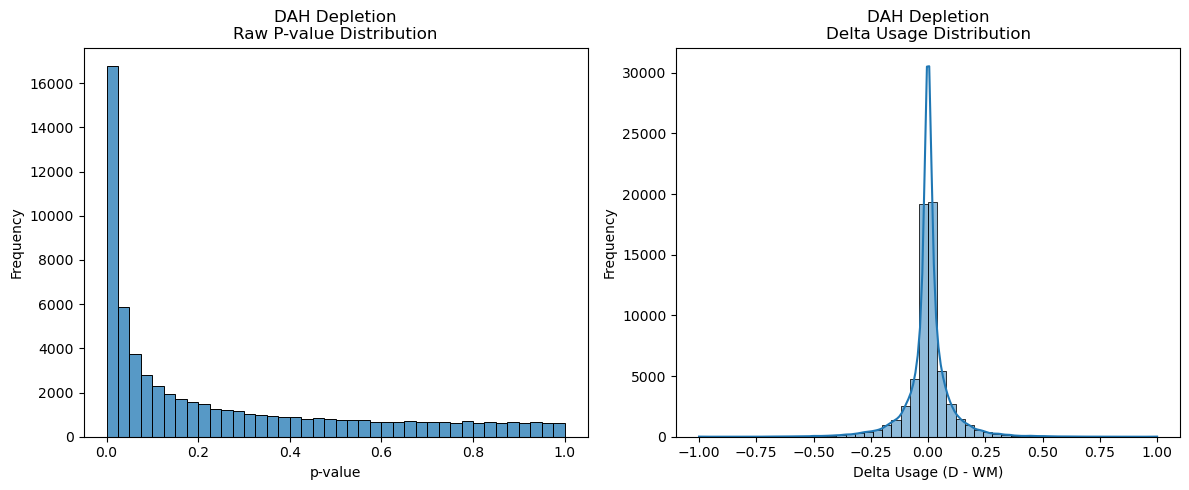


## 4. Logical Consistency ##
[OK] `delta_usage` is consistent with `mean_usage_D` - `mean_usage_WM`.
[OK] All significant isoforms have a non-zero delta_usage.

Sanity checks complete for this dataframe.



In [11]:
perform_sanity_checks(df_DAH, "DAH Depletion")

---------------------------------------------
🔬 Running Sanity Checks for: DEH Depletion
---------------------------------------------

## 1. Basic Data Integrity ##
Shape of the dataframe: 63204 rows, 14 columns

[OK] No missing values in 'pval', 'padj', or 'delta_usage'.

## 2. P-value Distribution ##
Plotting p-value histogram...

## 3. Effect Size (delta_usage) Sanity ##
Delta Usage Range: [-1.000, 1.000]
[OK] Delta usage values are within the expected [-1, 1] range.


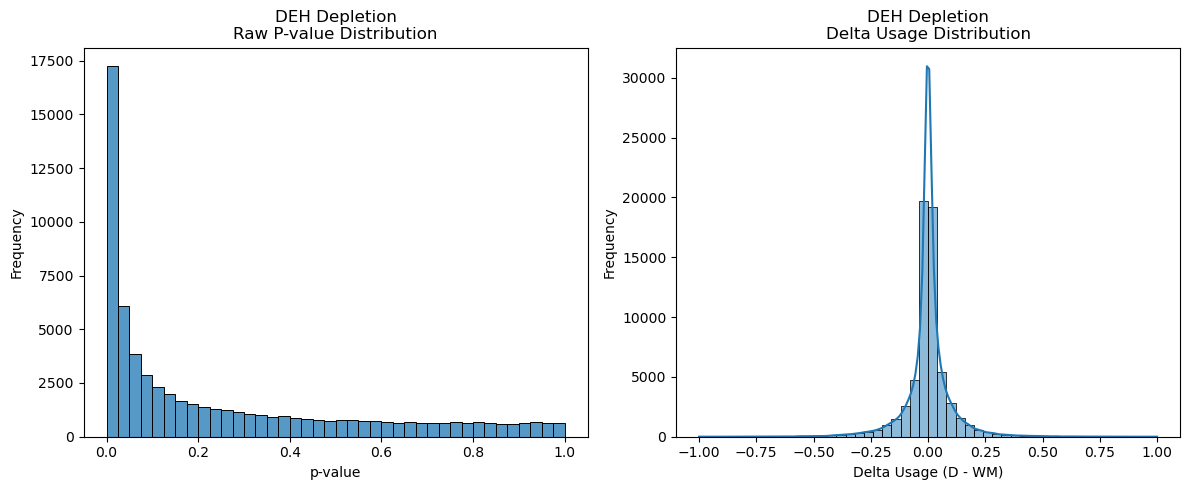


## 4. Logical Consistency ##
[OK] `delta_usage` is consistent with `mean_usage_D` - `mean_usage_WM`.
[OK] All significant isoforms have a non-zero delta_usage.

Sanity checks complete for this dataframe.



In [12]:
perform_sanity_checks(df_DEH, "DEH Depletion")

In [23]:
def generate_dtu_summary(df, title):
    """
    Generates a pie chart, volcano plot, and summary for DTU results.

    Args:
        df (pd.DataFrame): DataFrame with DTU results.
                           Must contain 'padj', 'pval', and 'delta_usage' columns.
        title (str): A title for the plots (e.g., 'D4500 Depletion').
    """
    # --- 1. Data Preparation ---
    alpha = 0.05  # Significance threshold for q-value
    delta_u_threshold = 0.25 # Threshold for large change in usage

    # Add a column for significance
    df['significant'] = df['padj'] < alpha

    # Add a column for the volcano plot y-axis, handling p-values of 0
    df['neg_log10_pval'] = -np.log10(df['pval'].replace(0, 1e-300))
    
    # Create a category column for coloring the volcano plot
    def assign_category(row):
        if not row['significant']:
            return 'not significant'
        if abs(row['delta_usage']) > delta_u_threshold:
            return f'Significant DTU (|ΔU| > {delta_u_threshold})'
        return 'significant'
        
    df['category'] = df.apply(assign_category, axis=1)

    # --- 2. Generate Plots ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Differential Isoform Usage: {title}', fontsize=16)

    # --- Plot 1: Pie Chart ---
    sig_counts = df['significant'].value_counts()
    labels = [f"not significant (n={sig_counts.get(False, 0)})", f"significant (n={sig_counts.get(True, 0)})"]
    sizes = [sig_counts.get(False, 0), sig_counts.get(True, 0)]
    colors = ['red', 'lightblue']
    
    axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[0].set_title('Change in Isoform Usage')
    axes[0].axis('equal') # Ensures pie is drawn as a circle.

    # --- Plot 2: Volcano Plot ---
    colors_volcano = {
        'not significant': 'blue',
        'significant': 'lightcoral',
        f'Significant DTU (|ΔU| > {delta_u_threshold})': 'red'
    }
    
    for category, color in colors_volcano.items():
        subset = df[df['category'] == category]
        axes[1].scatter(subset['delta_usage'], subset['neg_log10_pval'],
                        label=category, color=color, alpha=0.7, s=2)

    # Add threshold lines
    axes[1].axhline(y=-np.log10(alpha), color='gray', linestyle='--')
    axes[1].axvline(x=delta_u_threshold, color='black', linestyle='--')
    axes[1].axvline(x=-delta_u_threshold, color='black', linestyle='--')
    
    axes[1].set_title('Isoforms Differential Usage')
    axes[1].set_xlabel('Delta Usage')
    axes[1].set_ylabel('-log10(p-value)')
    axes[1].legend()
    axes[1].set_xlim(-0.9, 0.9) # Adjust limits as needed

    # --- 3. Print Summary ---
    increased_usage = df[(df['significant']) & (df['delta_usage'] > 0)].shape[0]
    print(f"{title}: {increased_usage:,} isoforms significantly increased in usage (q-value < {alpha})")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

D4500 Depletion: 2,064 isoforms significantly increased in usage (q-value < 0.05)


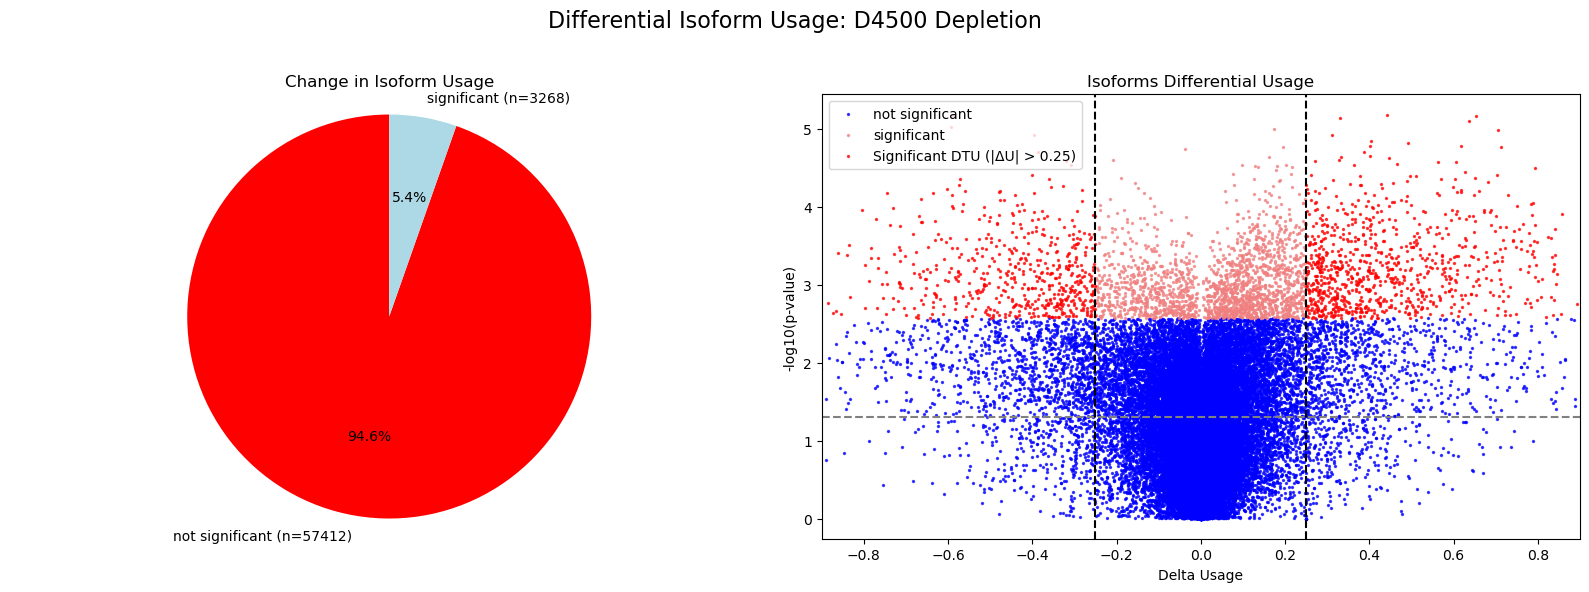

In [24]:
generate_dtu_summary(df_D4500, "D4500 Depletion")

DAH Depletion: 4,606 isoforms significantly increased in usage (q-value < 0.05)


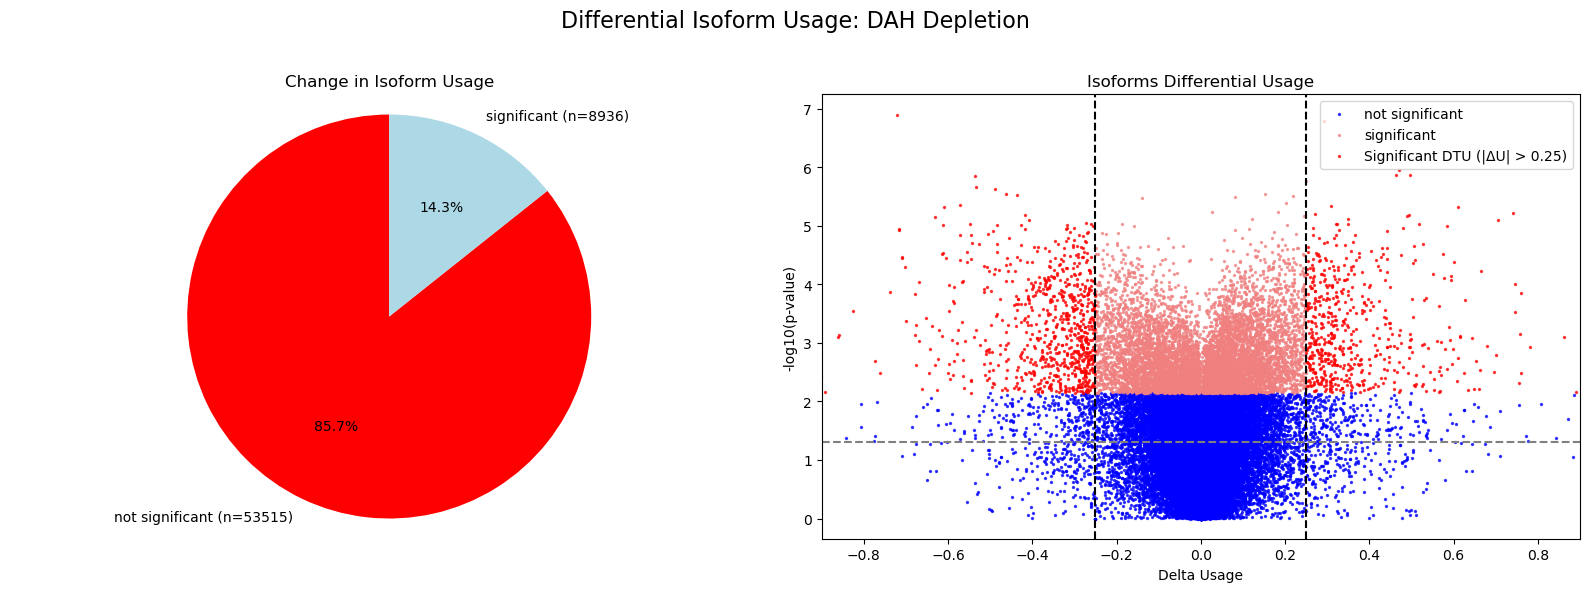

In [25]:
generate_dtu_summary(df_DAH, "DAH Depletion")

DEH Depletion: 4,764 isoforms significantly increased in usage (q-value < 0.05)


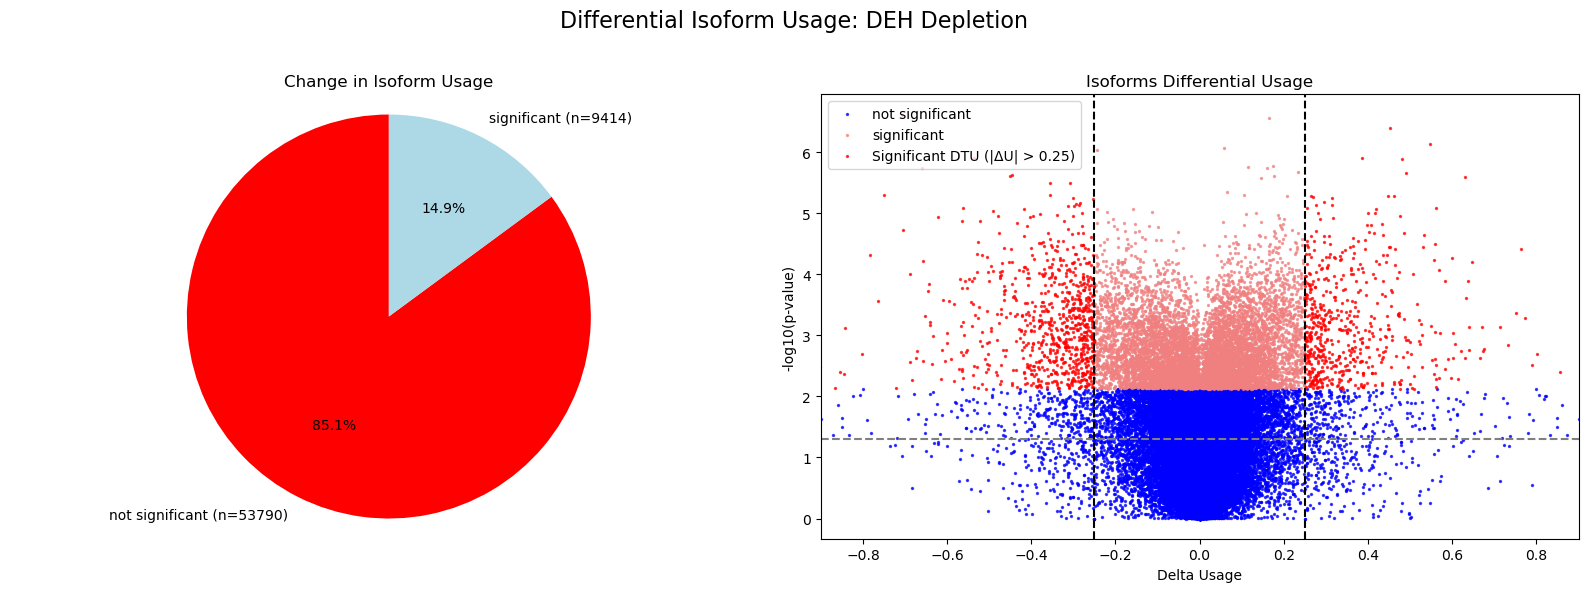

In [26]:
generate_dtu_summary(df_DEH, "DEH Depletion")

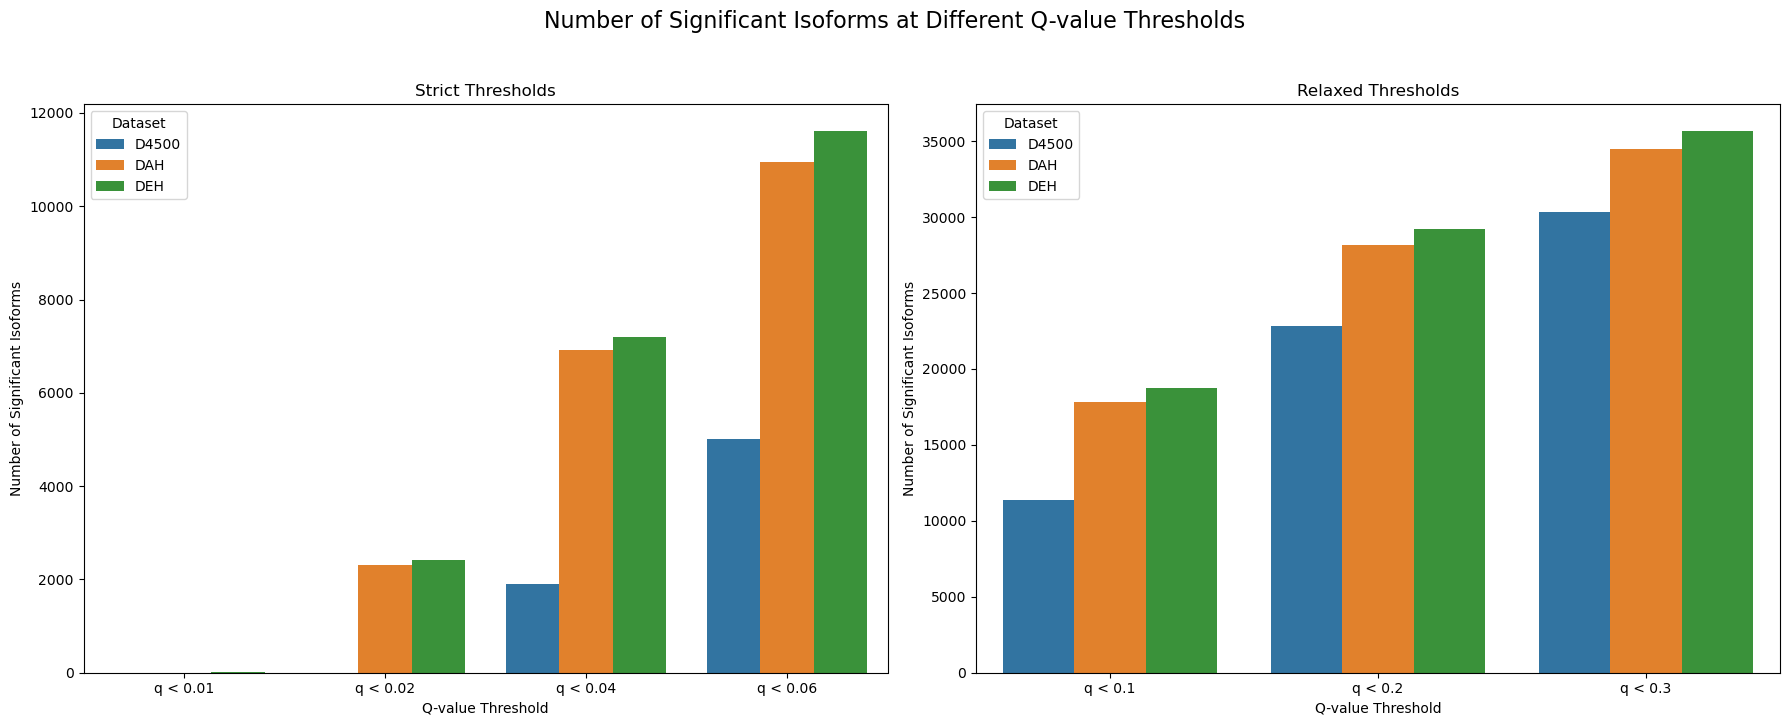

In [31]:
# Define the q-value thresholds
q_values_strict = [0.01, 0.02, 0.04, 0.06]
q_values_relaxed = [0.10, 0.20, 0.30]
all_q_values = q_values_strict + q_values_relaxed

# Store dataframes and their names
datasets = {
    'D4500': df_D4500,
    'DAH': df_DAH,
    'DEH': df_DEH
}

# --- 1. Calculate counts (same as before) ---
results_list = []
for name, df in datasets.items():
    for q_val in all_q_values:
        # Count isoforms where padj is less than the threshold
        count = df[df['padj'] < q_val].shape[0]
        
        results_list.append({
            'dataset': name,
            'q_value_str': f'q < {q_val}', # For clear plot labels
            'q_value': q_val,
            'significant_count': count
        })

# Convert the results list to a DataFrame for plotting
counts_df = pd.DataFrame(results_list)

# --- 2. Create the two plots (with x and hue swapped) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Number of Significant Isoforms at Different Q-value Thresholds', fontsize=16, y=1.03)

# --- Plot 1: Strict Q-values ---
plot_data_strict = counts_df[counts_df['q_value'].isin(q_values_strict)]
# Order the x-axis correctly
plot_data_strict = plot_data_strict.sort_values(by='q_value')

sns.barplot(data=plot_data_strict, 
            x='q_value_str',        # Changed from 'dataset'
            y='significant_count', 
            hue='dataset',          # Changed from 'q_value_str'
            ax=axes[0])

axes[0].set_title('Strict Thresholds')
axes[0].set_xlabel('Q-value Threshold') # Updated label
axes[0].set_ylabel('Number of Significant Isoforms')
axes[0].legend(title='Dataset')       # Updated legend

# --- Plot 2: Relaxed Q-values ---
plot_data_relaxed = counts_df[counts_df['q_value'].isin(q_values_relaxed)]
# Order the x-axis correctly
plot_data_relaxed = plot_data_relaxed.sort_values(by='q_value')

sns.barplot(data=plot_data_relaxed, 
            x='q_value_str',        # Changed from 'dataset'
            y='significant_count', 
            hue='dataset',          # Changed from 'q_value_str'
            ax=axes[1])

axes[1].set_title('Relaxed Thresholds')
axes[1].set_xlabel('Q-value Threshold') # Updated label
axes[1].set_ylabel('Number of Significant Isoforms')
axes[1].legend(title='Dataset')       # Updated legend

plt.tight_layout()
plt.show()

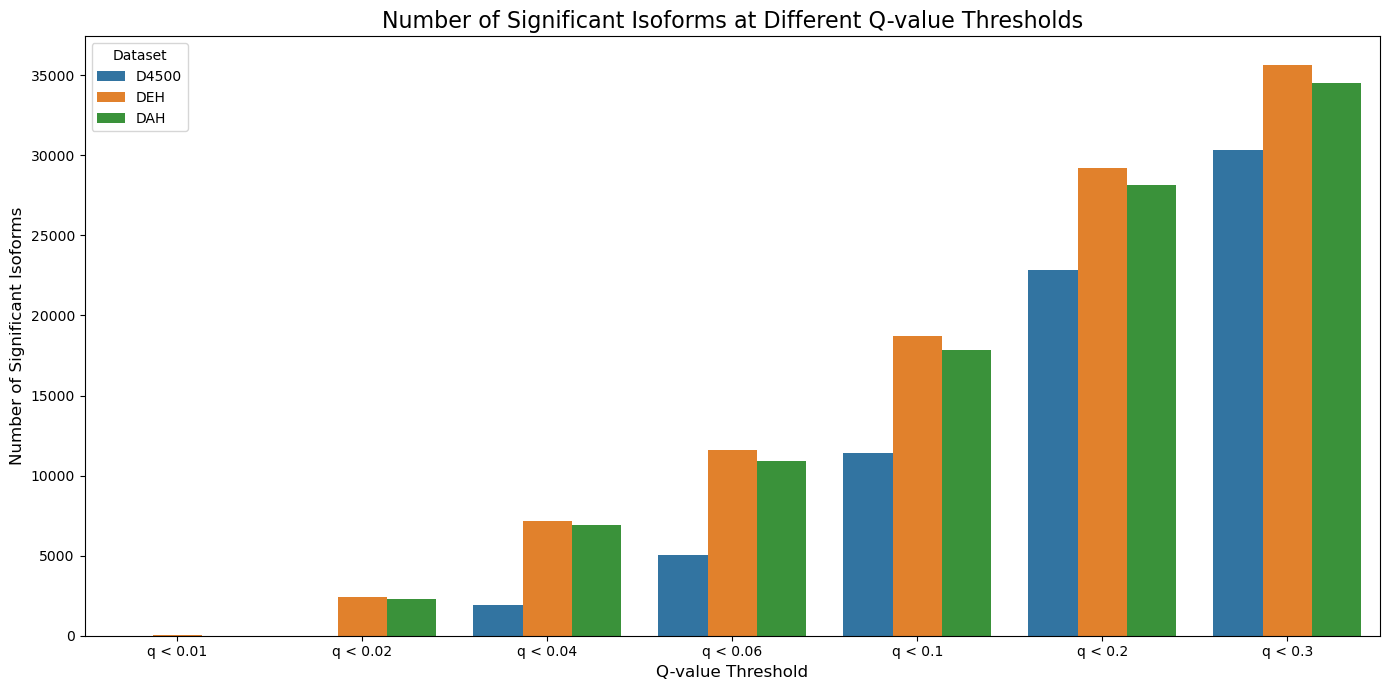

In [33]:
# --- 1. Define your inputs (easy to change) ---

# A dictionary of the dataframes you want to compare
datasets = {
    'D4500': df_D4500,
    'DAH': df_DAH,
    'DEH': df_DEH
}

# The list of q-value thresholds you want to plot
q_value_thresholds = [0.01, 0.02, 0.04, 0.06, 0.1, 0.2, 0.3]

# --- 2. Calculate counts for all datasets and q-values ---
results_list = []
for name, df in datasets.items():
    for q_val in q_value_thresholds:
        # Count isoforms where padj is less than the threshold
        count = df[df['padj'] < q_val].shape[0]
        
        results_list.append({
            'dataset': name,
            'q_value_str': f'q < {q_val}', # For clear plot labels
            'q_value': q_val,
            'significant_count': count
        })

# Convert the results list to a DataFrame for plotting
counts_df = pd.DataFrame(results_list)

# --- 3. Sort the DataFrame by q-value ---
# This ensures the x-axis groups are in the correct numerical order
counts_df = counts_df.sort_values(by='q_value')

# --- 4. Create the single, wide plot ---
plt.figure(figsize=(14, 7)) # Width of 14 for 7 groups
sns.barplot(data=counts_df, 
            x='q_value_str', 
            y='significant_count', 
            hue='dataset')

plt.title('Number of Significant Isoforms at Different Q-value Thresholds', fontsize=16)
plt.xlabel('Q-value Threshold', fontsize=12)
plt.ylabel('Number of Significant Isoforms', fontsize=12)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

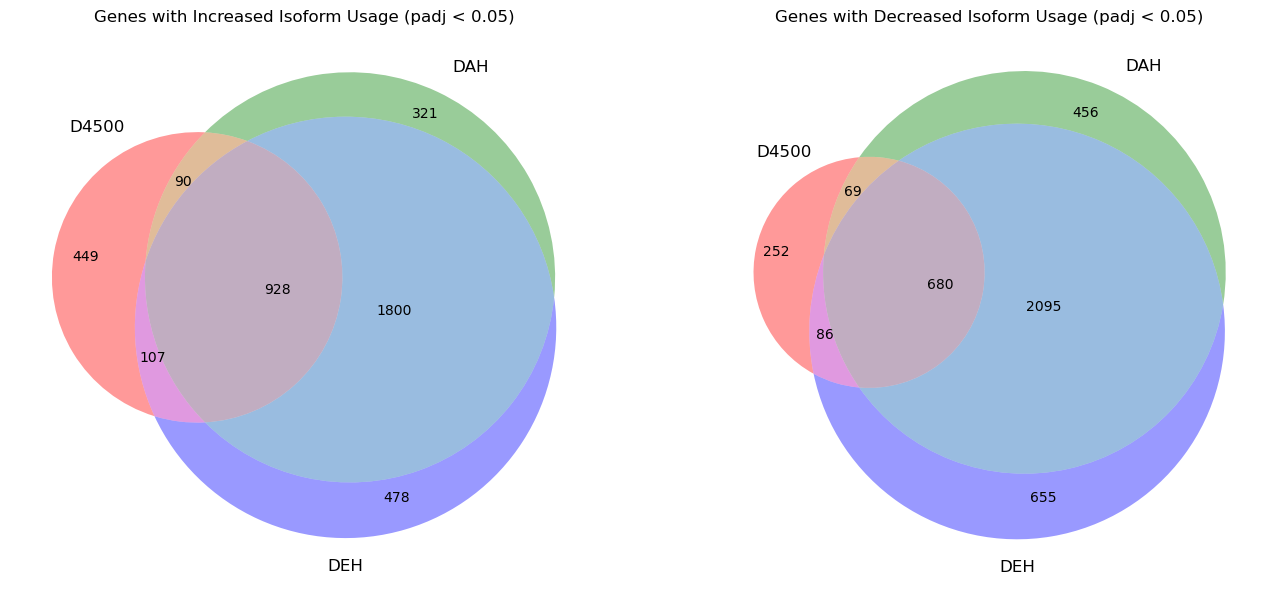

In [5]:
# Assume your dataframes df_D4500, df_DAH, and df_DEH are already loaded

def get_significant_genes(df, direction='up', q_value_threshold=0.05):
    """Extracts a set of significant gene IDs from a DTU result dataframe."""
    significant_df = df[df['padj'] < q_value_threshold]
    
    if direction == 'up':
        # Genes with at least one isoform showing significant increased usage
        target_df = significant_df[significant_df['delta_usage'] > 0]
    elif direction == 'down':
        # Genes with at least one isoform showing significant decreased usage
        target_df = significant_df[significant_df['delta_usage'] < 0]
    else:
        # All genes with any significant isoform
        target_df = significant_df
        
    return set(target_df['gene_id'])

# --- Get Sets for Genes with INCREASED Isoform Usage ---
up_genes_d4500 = get_significant_genes(df_D4500, direction='up')
up_genes_dah = get_significant_genes(df_DAH, direction='up')
up_genes_deh = get_significant_genes(df_DEH, direction='up')

# --- Get Sets for Genes with DECREASED Isoform Usage ---
down_genes_d4500 = get_significant_genes(df_D4500, direction='down')
down_genes_dah = get_significant_genes(df_DAH, direction='down')
down_genes_deh = get_significant_genes(df_DEH, direction='down')

# --- Create Venn Diagrams ---
plt.figure(figsize=(14, 6))

# Plot for INCREASED usage
plt.subplot(1, 2, 1)
venn3([up_genes_d4500, up_genes_dah, up_genes_deh],
      set_labels=('D4500', 'DAH', 'DEH'))
plt.title('Genes with Increased Isoform Usage (padj < 0.05)')

# Plot for DECREASED usage
plt.subplot(1, 2, 2)
venn3([down_genes_d4500, down_genes_dah, down_genes_deh],
      set_labels=('D4500', 'DAH', 'DEH'))
plt.title('Genes with Decreased Isoform Usage (padj < 0.05)')

plt.tight_layout()
plt.show()

Found 1314 genes significant in all three experiments.

Calculating similarity scores for each pair of experiments...
Calculation complete.


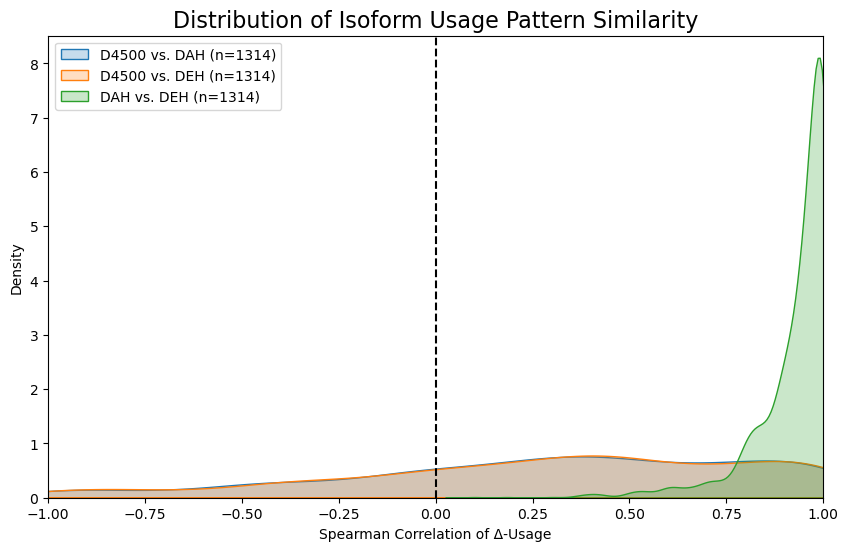

In [17]:
# --- 1. Identify Common Genes ---
# First, get all significant genes (up or down) from each experiment
all_sig_genes_d4500 = get_significant_genes(df_D4500, direction='all')
all_sig_genes_dah = get_significant_genes(df_DAH, direction='all')
all_sig_genes_deh = get_significant_genes(df_DEH, direction='all')

# Find the intersection of genes significant in all three
common_genes = all_sig_genes_d4500 & all_sig_genes_dah & all_sig_genes_deh
print(f"Found {len(common_genes)} genes significant in all three experiments.")

# --- 2. Calculate Similarity Scores for Each Gene ---
def get_similarity_scores(df1, df2, gene_list):
    """Calculates Spearman correlation of delta_usage for each gene between two dataframes."""
    correlations = []
    for gene in gene_list:
        # Get all isoforms for the current gene from both dataframes
        isoforms1 = df1[df1['gene_id'] == gene][['isoform_id', 'delta_usage']]
        isoforms2 = df2[df2['gene_id'] == gene][['isoform_id', 'delta_usage']]
        
        # Merge to align isoforms. This is crucial!
        merged_isoforms = pd.merge(isoforms1, isoforms2, on='isoform_id', suffixes=('_1', '_2'))
        
        # We need at least 2 common isoforms to calculate correlation
        if len(merged_isoforms) > 1:
            # Calculate Spearman correlation
            corr, _ = spearmanr(merged_isoforms['delta_usage_1'], merged_isoforms['delta_usage_2'])
            correlations.append(corr)
            
    return correlations

# --- 3. Collect Scores for All Dataset Pairs ---
print("\nCalculating similarity scores for each pair of experiments...")
# It is important to remove NaN values before plotting
sim_d4500_vs_dah = [x for x in get_similarity_scores(df_D4500, df_DAH, common_genes) if not np.isnan(x)]
sim_d4500_vs_deh = [x for x in get_similarity_scores(df_D4500, df_DEH, common_genes) if not np.isnan(x)]
sim_dah_vs_deh = [x for x in get_similarity_scores(df_DAH, df_DEH, common_genes) if not np.isnan(x)]
print("Calculation complete.")

# --- 4. Visualize the Distributions ---
plt.figure(figsize=(10, 6))
sns.kdeplot(sim_d4500_vs_dah, label=f'D4500 vs. DAH (n={len(sim_d4500_vs_dah)})', fill=True)
sns.kdeplot(sim_d4500_vs_deh, label=f'D4500 vs. DEH (n={len(sim_d4500_vs_deh)})', fill=True)
sns.kdeplot(sim_dah_vs_deh, label=f'DAH vs. DEH (n={len(sim_dah_vs_deh)})', fill=True)

plt.title('Distribution of Isoform Usage Pattern Similarity', fontsize=16)
plt.xlabel('Spearman Correlation of Δ-Usage')
plt.ylabel('Density')
plt.xlim(-1, 1)
plt.axvline(0, color='black', linestyle='--')
plt.legend()
plt.show()

Plotting D4500 vs. DAH...
Plotting D4500 vs. DEH...
Plotting DAH vs. DEH...


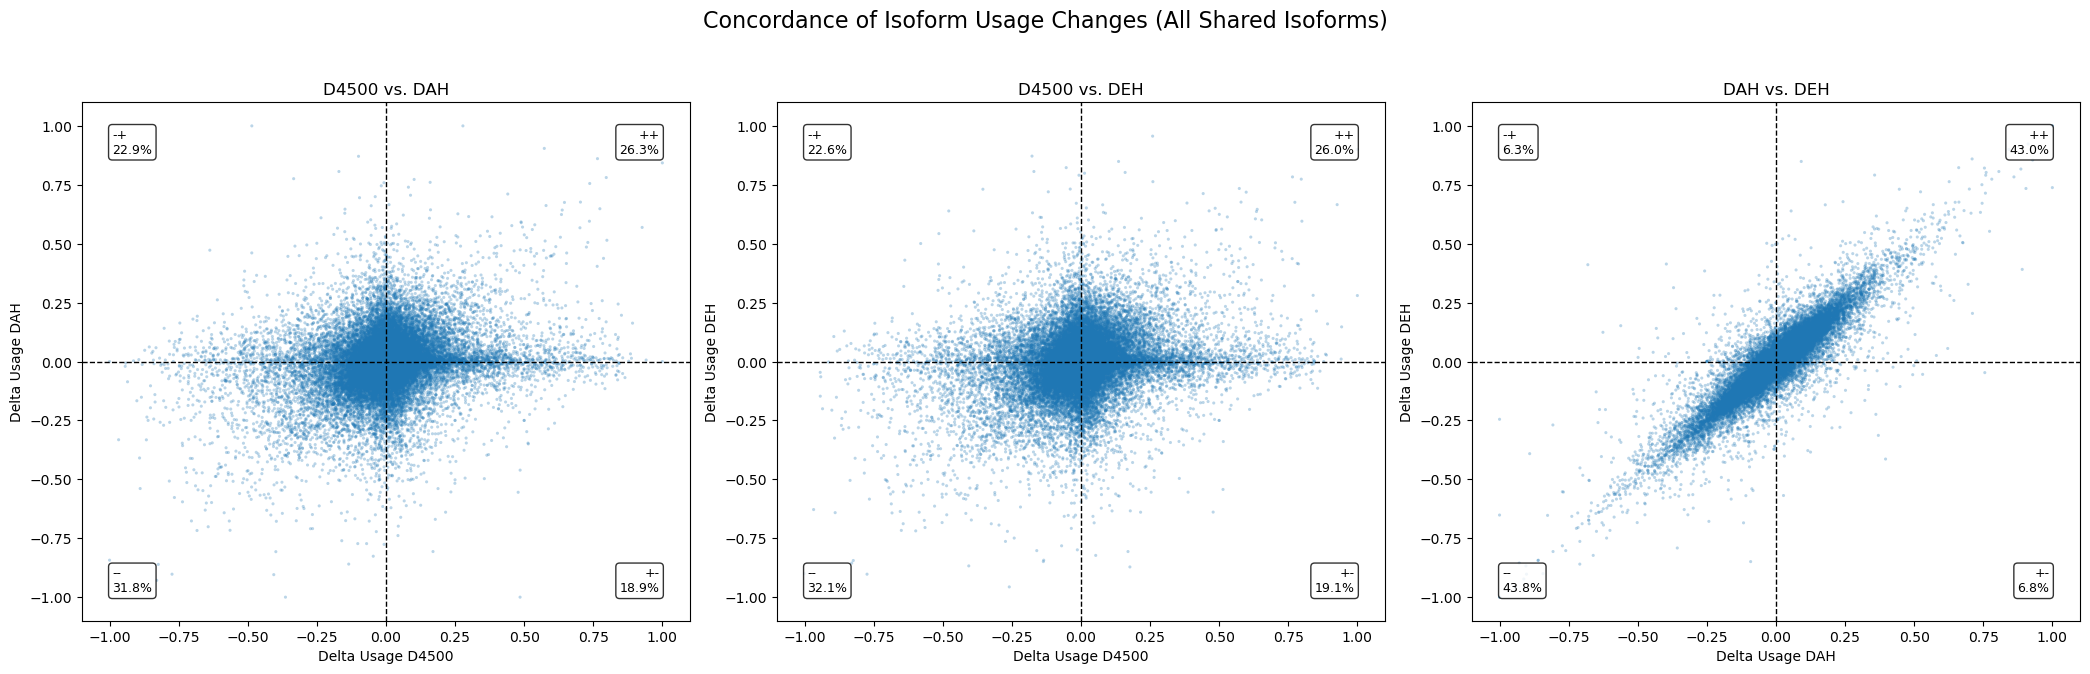

In [27]:
def plot_quadrant_scatter(df1, df2, name1, name2, ax):
    """
    Merges two DTU dataframes on shared isoforms and creates a 
    scatter plot with quadrants.
    
    Args:
        df1 (pd.DataFrame): First results dataframe.
        df2 (pd.DataFrame): Second results dataframe.
        name1 (str): Label for the first dataframe (e.g., 'D4500').
        name2 (str): Label for the second dataframe (e.g., 'DAH').
        ax (matplotlib.axes.Axes): The axis object to plot on.
    """
    # 1. Merge the dataframes on shared isoforms
    col1, col2 = f'delta_usage_{name1}', f'delta_usage_{name2}'
    merged_df = pd.merge(
        df1[['isoform_id', 'delta_usage']],
        df2[['isoform_id', 'delta_usage']],
        on='isoform_id',
        suffixes=(f'_{name1}', f'_{name2}')
    )
    
    if merged_df.empty:
        ax.text(0.5, 0.5, "No shared isoforms found", horizontalalignment='center', 
                verticalalignment='center', transform=ax.transAxes)
        ax.set_title(f"{name1} vs. {name2}")
        return

    # 2. Calculate quadrant percentages
    total_points = len(merged_df)
    pp = len(merged_df[(merged_df[col1] > 0) & (merged_df[col2] > 0)]) # Plus-Plus
    pm = len(merged_df[(merged_df[col1] > 0) & (merged_df[col2] < 0)]) # Plus-Minus
    mp = len(merged_df[(merged_df[col1] < 0) & (merged_df[col2] > 0)]) # Minus-Plus
    mm = len(merged_df[(merged_df[col1] < 0) & (merged_df[col2] < 0)]) # Minus-Minus

    # 3. Create the scatter plot
    sns.scatterplot(data=merged_df, x=col1, y=col2, 
                    alpha=0.3, s=5, ax=ax, edgecolor='none')
    
    # 4. Add quadrant lines
    ax.axhline(0, color='black', linestyle='--', lw=1)
    ax.axvline(0, color='black', linestyle='--', lw=1)
    
    # 5. Add quadrant labels with percentages
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    
    # Top-Right (++)
    ax.text(0.95, 0.95, f'++\n{pp/total_points*100:.1f}%', transform=ax.transAxes, 
            ha='right', va='top', fontsize=9, bbox=props)
    # Top-Left (-+)
    ax.text(0.05, 0.95, f'-+\n{mp/total_points*100:.1f}%', transform=ax.transAxes, 
            ha='left', va='top', fontsize=9, bbox=props)
    # Bottom-Right (+-)
    ax.text(0.95, 0.05, f'+-\n{pm/total_points*100:.1f}%', transform=ax.transAxes, 
            ha='right', va='bottom', fontsize=9, bbox=props)
    # Bottom-Left (--)
    ax.text(0.05, 0.05, f'--\n{mm/total_points*100:.1f}%', transform=ax.transAxes, 
            ha='left', va='bottom', fontsize=9, bbox=props)
    
    ax.set_title(f"{name1} vs. {name2}")
    ax.set_xlabel(f"Delta Usage {name1}")
    ax.set_ylabel(f"Delta Usage {name2}")
    
    # Set axis limits to be symmetrical and consistent
    max_val = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]), 
                  abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)

# --- How to Use the Code ---

# Assume your three dataframes are loaded:
# df_D4500, df_DAH, df_DEH

# Create a 1x3 figure to hold the plots
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))

print("Plotting D4500 vs. DAH...")
plot_quadrant_scatter(df_D4500, df_DAH, 'D4500', 'DAH', axes[0])

print("Plotting D4500 vs. DEH...")
plot_quadrant_scatter(df_D4500, df_DEH, 'D4500', 'DEH', axes[1])

print("Plotting DAH vs. DEH...")
plot_quadrant_scatter(df_DAH, df_DEH, 'DAH', 'DEH', axes[2])

fig.suptitle('Concordance of Isoform Usage Changes (All Shared Isoforms)', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

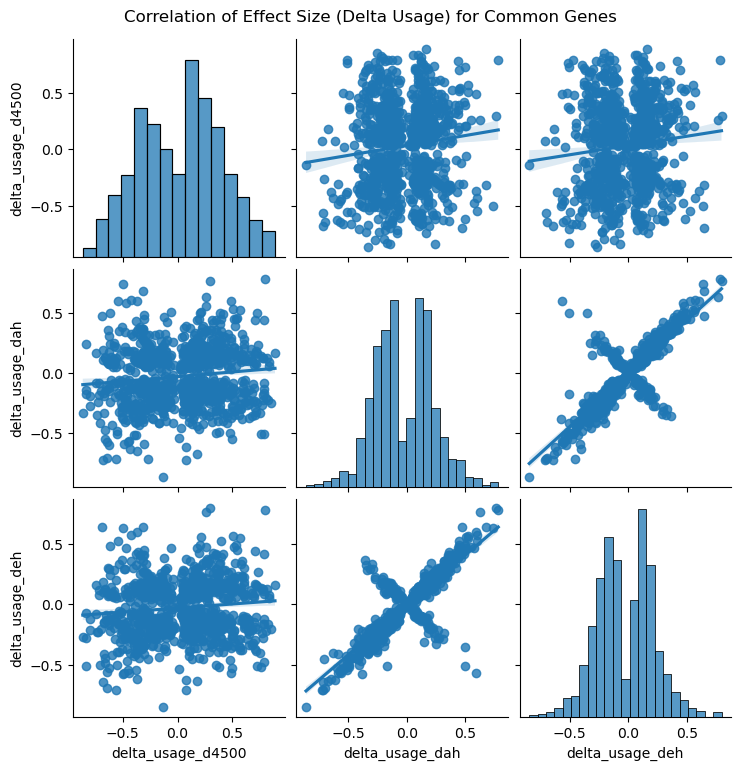

In [18]:
# First, find the genes common to all three (using the 'up' sets as an example)
common_genes = up_genes_d4500 & up_genes_dah & up_genes_deh

def get_max_abs_delta_usage(df, gene_set):
    """
    For each gene in the list, find the isoform with the largest
    absolute value of delta_usage.
    """
    # Filter for relevant genes first
    subset_df = df[df['gene_id'].isin(gene_set)].copy()
    
    # Find the index of the row with the max absolute delta_usage for each gene
    idx = subset_df.groupby('gene_id')['delta_usage'].apply(lambda x: x.abs().idxmax())
    
    # Return the rows corresponding to those indices
    return subset_df.loc[idx]

# Get the data for the common genes from each experiment
common_d4500 = get_max_abs_delta_usage(df_D4500, common_genes)
common_dah = get_max_abs_delta_usage(df_DAH, common_genes)
common_deh = get_max_abs_delta_usage(df_DEH, common_genes)

# Merge them into a single dataframe for plotting
merged_df = pd.merge(
    common_d4500[['gene_id', 'delta_usage']],
    common_dah[['gene_id', 'delta_usage']],
    on='gene_id', suffixes=('_d4500', '_dah')
)
merged_df = pd.merge(
    merged_df,
    common_deh[['gene_id', 'delta_usage']],
    on='gene_id'
).rename(columns={'delta_usage': 'delta_usage_deh'})

# Create the scatter plot matrix
sns.pairplot(merged_df,
             vars=['delta_usage_d4500', 'delta_usage_dah', 'delta_usage_deh'],
             kind='reg') # 'reg' adds a regression line
plt.suptitle('Correlation of Effect Size (Delta Usage) for Common Genes', y=1.02)
plt.show()

# Next (done)

- Show number of isoforms for each datatset across 3 q-values: bar plot (y axis is counts and x axis is datasets * q-value).Pick q-values such that plot looks good. Maybe do two plots (one q-values 0.01, 0.03, 0.05; the other one q-values 0.10, 0.20, 0.30) (done)

- Take all data, create three scatterplots of D4500/DAH, D4500/DEH and DEH/DAH. Delta usage for each. Put a lines on top so that you create 4 quadrants. (done)

- Try to reduce the size of the dots in the vulcano plots and see if difference is more visible. (done)